In [7]:
import sys

sys.path.append("../..")
import pandas as pd


from src.data_service.database_manager import Database

db = Database()

print("Database connected successfully.")

Database connected successfully.


In [8]:
full_df = db.fetch_all()

print("Total readings retrieved from database:", len(full_df))
display(full_df.head())

Total readings retrieved from database: 10


c:\Users\pree0\OneDrive\Desktop\Conestoga_Projects\Foundations_Of_Machine_Learning_Frameworks\DataEngineeringOneAssignment\src\energy_consumption\../..\src\data_service\database_manager.py:102: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM {self.table_name}", self.connection)


,id,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,axis_9,axis_10,axis_11,axis_12,axis_13,axis_14,time
0,1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:53.706Z
1,2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:55.575Z
2,3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:57.492Z
3,4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:59.409Z
4,5,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:19:01.276Z


In [9]:
electrical_axes = [
    "axis_1",
    "axis_2",
    "axis_3",
    "axis_4",
    "axis_5",
    "axis_6",
    "axis_7",
    "axis_8"
]

# Convert the readings from text to numbers
for axis in electrical_axes:
    full_df[axis] = pd.to_numeric(full_df[axis], errors="coerce")

print("Electrical readings prepared.")

Electrical readings prepared.


In [10]:
full_df["Total_Electrical_Reading"] = full_df[electrical_axes].sum(axis=1)

print("Total electrical readings calculated.")
display(
    full_df[
        ["time"] + electrical_axes + ["Total_Electrical_Reading"]
    ].head()
)

Total electrical readings calculated.


,time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,Total_Electrical_Reading
0,2022-10-17T12:18:53.706Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17T12:18:55.575Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17T12:18:57.492Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17T12:18:59.409Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17T12:19:01.276Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


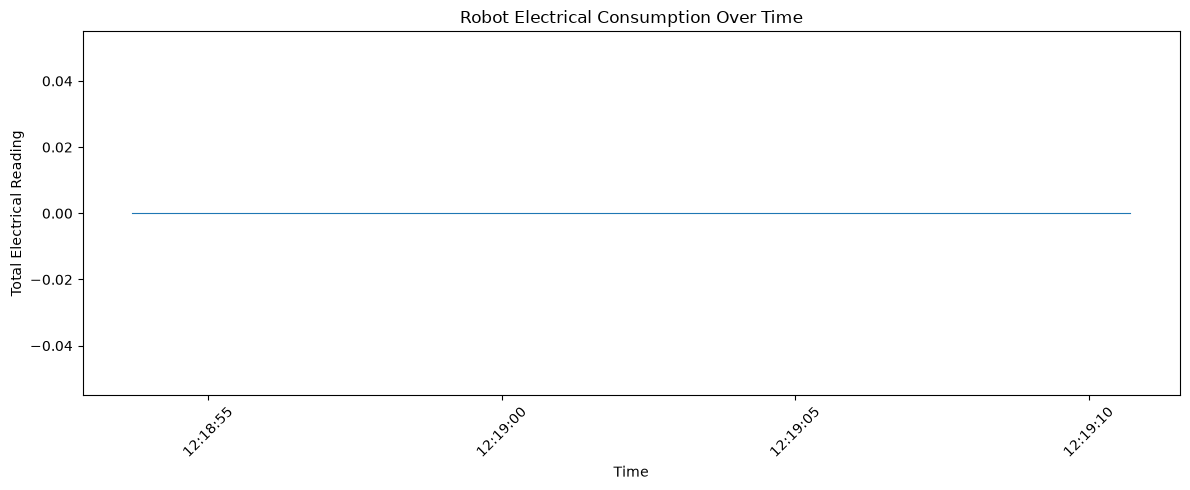

In [11]:
import matplotlib.pyplot as plt

full_df["time"] = pd.to_datetime(full_df["time"])

plt.figure(figsize=(12, 5))

plt.plot(
    full_df["time"],
    full_df["Total_Electrical_Reading"],
    linewidth=0.8
)

plt.title("Robot Electrical Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Total Electrical Reading")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()